In [1]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

from utils.data_utils import load_and_preprocess_data, vectorize_text
from utils.model_utils import evaluate_model

In [2]:
# Set random seed for reproducibility
RANDOM_STATE = 42

In [ ]:
# Load and preprocess the Enron spam data
X, y, df = load_and_preprocess_data(
    '../../data/enron_spam_data.csv',
    text_columns=['Subject', 'Message'],
    target_column='Spam/Ham',
    positive_class='spam',
    combine_text=True
)

Loading data from ../data/enron_spam_data.csv...
Dataset shape: (33716, 5)

Column names: ['Message ID', 'Subject', 'Message', 'Spam/Ham', 'Date']

First few rows:
   Message ID                       Subject  \
0           0  christmas tree farm pictures   
1           1      vastar resources , inc .   
2           2  calpine daily gas nomination   
3           3                    re : issue   
4           4     meter 7268 nov allocation   

                                             Message Spam/Ham        Date  
0                                                NaN      ham  1999-12-10  
1  gary , production from the high island larger ...      ham  1999-12-13  
2             - calpine daily gas nomination 1 . doc      ham  1999-12-14  
3  fyi - see note below - already done .\nstella\...      ham  1999-12-14  
4  fyi .\n- - - - - - - - - - - - - - - - - - - -...      ham  1999-12-14  

Dropped 609 rows with NaN values
Shape after dropping NaN: (33107, 5)

Combined text columns: ['

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=RANDOM_STATE,
    stratify=y # Maintain class distribution in splits
)

In [5]:
X_train_vec, X_test_vec, vectorizer = vectorize_text(
    X_train, X_test,
    method='tfidf',
    max_features=5000,
    min_df=2, # Ignore terms that appear in fewer than 2 documents
    ngram_range=(1, 2), # Use unigrams and bigrams
    stop_words='english' # Remove common English filler words
)

Vectorizing text using TFIDF...
Training set shape: (26485, 5000)
Test set shape: (6622, 5000)
Vocabulary size: 5000


In [6]:
# Initialize and train SVM classifier
# Using linear kernel to allow for feature importance inspection
# probability=True is needed for predict_proba in the testing section
svm_classifier = SVC(kernel='linear', probability=True, random_state=RANDOM_STATE)
print("Training SVM classifier... (this may take a moment)")
svm_classifier.fit(X_train_vec, y_train)

Training SVM classifier... (this may take a moment)


,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [7]:
# Predict on training set
y_train_pred = svm_classifier.predict(X_train_vec)

# Predict on test set
y_test_pred = svm_classifier.predict(X_test_vec)

In [8]:
# Evaluate on training set
train_metrics = evaluate_model(y_train, y_train_pred, "Training Set")

# Evaluate on test set
test_metrics = evaluate_model(y_test, y_test_pred, "Test Set")

# Print detailed classification report
print("\nDetailed Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred, target_names=['Ham', 'Spam']))

Training Set Metrics:
Accuracy:  0.9954
Precision: 0.9930
Recall:    0.9977
F1-Score:  0.9954
Test Set Metrics:
Accuracy:  0.9890
Precision: 0.9851
Recall:    0.9931
F1-Score:  0.9891

Detailed Classification Report (Test Set):
              precision    recall  f1-score   support

         Ham       0.99      0.98      0.99      3299
        Spam       0.99      0.99      0.99      3323

    accuracy                           0.99      6622
   macro avg       0.99      0.99      0.99      6622
weighted avg       0.99      0.99      0.99      6622



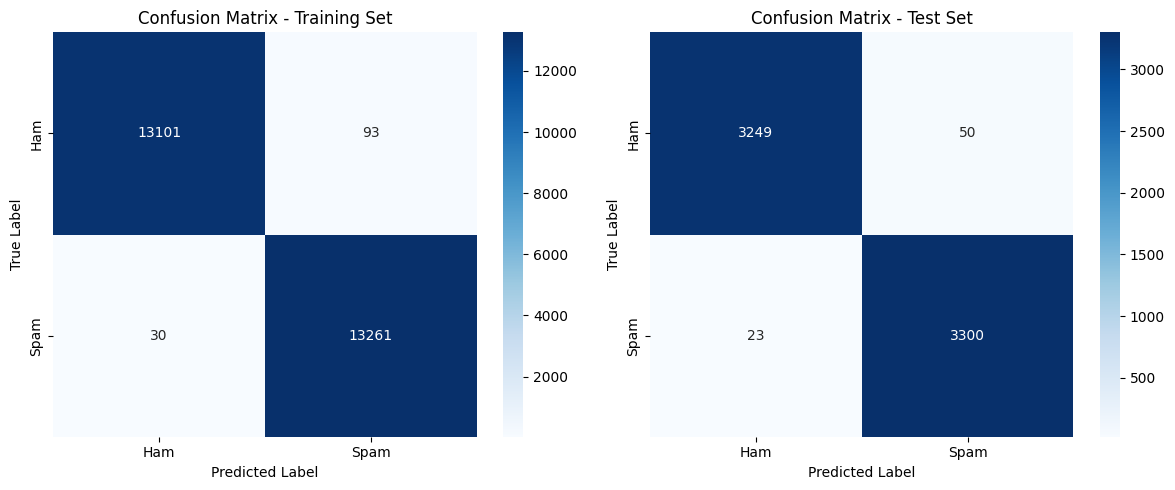

In [9]:
# Visualize with confusion matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Training set confusion matrix
cm_train = confusion_matrix(y_train, y_train_pred)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
axes[0].set_title('Confusion Matrix - Training Set')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Test set confusion matrix
cm_test = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
axes[1].set_title('Confusion Matrix - Test Set')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

In [10]:
# Show top features for each class
# For Linear SVM, we can look at the coefficients
# Positive coefficients -> Spam (Class 1)
# Negative coefficients -> Ham (Class 0)

def get_top_features_svm(vectorizer, classifier, n=20):
    """Get top features (words) for each class based on SVM coefficients."""
    feature_names = vectorizer.get_feature_names_out()
    
    # Get coefficients (shape is [1, n_features] for binary classification)
    # Convert sparse matrix to dense array if necessary
    if hasattr(classifier.coef_, 'toarray'):
        coefs = classifier.coef_.toarray()[0]
    else:
        coefs = classifier.coef_[0]
    
    # Top features for Ham (most negative coefficients)
    ham_indices = coefs.argsort()[:n]
    top_ham = [(feature_names[i], coefs[i]) for i in ham_indices]
    
    # Top features for Spam (most positive coefficients)
    spam_indices = coefs.argsort()[-n:][::-1]
    top_spam = [(feature_names[i], coefs[i]) for i in spam_indices]
    
    return top_ham, top_spam

top_ham, top_spam = get_top_features_svm(vectorizer, svm_classifier, n=15)

print("Top 15 Ham (Legitimate) Email Features (Negative Coefficients):")
for i, (word, coef) in enumerate(top_ham, 1):
    print(f"{i:2d}. {word:20s} (coef: {coef:.4f})")

print("\nTop 15 Spam Email Features (Positive Coefficients):")
for i, (word, coef) in enumerate(top_spam, 1):
    print(f"{i:2d}. {word:20s} (coef: {coef:.4f})")

Top 15 Ham (Legitimate) Email Features (Negative Coefficients):
 1. enron                (coef: -6.5064)
 2. vince                (coef: -3.9136)
 3. louise               (coef: -3.6665)
 4. attached             (coef: -3.3046)
 5. thanks               (coef: -3.2866)
 6. 713                  (coef: -2.7253)
 7. let know             (coef: -2.7103)
 8. questions            (coef: -2.6840)
 9. daren                (coef: -2.5319)
10. 2001                 (coef: -2.4936)
11. enron com            (coef: -2.4244)
12. dave                 (coef: -2.3347)
13. doc                  (coef: -2.2974)
14. energy               (coef: -2.2576)
15. password             (coef: -2.2277)

Top 15 Spam Email Features (Positive Coefficients):
 1. 2005                 (coef: 3.3725)
 2. 2004                 (coef: 3.2561)
 3. remove               (coef: 2.7552)
 4. mobile               (coef: 1.9481)
 5. em                   (coef: 1.7973)
 6. software             (coef: 1.7951)
 7. http                 (co

In [11]:
# Test on new samples

def predict_email(text, vectorizer, classifier):
    """Predict whether a new email is spam or ham."""
    text_vec = vectorizer.transform([text])
    prediction = classifier.predict(text_vec)[0]
    probability = classifier.predict_proba(text_vec)[0]
    
    label = "SPAM" if prediction == 1 else "HAM"
    confidence = probability[prediction]
    
    return label, confidence

# Test examples
test_examples = [
    "Meeting scheduled for tomorrow at 10am in conference room B",
    "CONGRATULATIONS! You've WON $1,000,000! Click here to claim NOW!!!",
    "Hi, can you send me the quarterly report by end of day?",
    "FREE MONEY! LIMITED TIME OFFER! BUY NOW!"
]

for i, example in enumerate(test_examples, 1):
    label, confidence = predict_email(example, vectorizer, svm_classifier)
    print(f"Example {i}:")
    print(f"Text: {example}")
    print(f"Prediction: {label} (Confidence: {confidence:.2%})")

Example 1:
Text: Meeting scheduled for tomorrow at 10am in conference room B
Prediction: HAM (Confidence: 100.00%)
Example 2:
Text: CONGRATULATIONS! You've WON $1,000,000! Click here to claim NOW!!!
Prediction: SPAM (Confidence: 91.21%)
Example 3:
Text: Hi, can you send me the quarterly report by end of day?
Prediction: HAM (Confidence: 81.78%)
Example 4:
Text: FREE MONEY! LIMITED TIME OFFER! BUY NOW!
Prediction: SPAM (Confidence: 100.00%)


## Save Model and Vectorizer

Save the trained model and vectorizer for use in the pipeline notebook.

In [ ]:
import joblib
import os

# Create models directory if it doesn't exist
models_dir = '../../models'
os.makedirs(models_dir, exist_ok=True)

# Save the model and vectorizer
joblib.dump(svm_classifier, os.path.join(models_dir, 'svm_model.joblib'))
joblib.dump(vectorizer, os.path.join(models_dir, 'svm_vectorizer.joblib'))

print(f"Model saved to {models_dir}/svm_model.joblib")
print(f"Vectorizer saved to {models_dir}/svm_vectorizer.joblib")

Model saved to ../models/svm_model.joblib
Vectorizer saved to ../models/svm_vectorizer.joblib
